In [1]:
import numpy as np
import pandas as pd
import astropy.units as u
import os
from scipy.interpolate import interp1d
from ptarcade.models_utils import g_rho, g_s
from scipy.optimize import minimize_scalar
from scipy.ndimage import gaussian_filter1d

In [2]:
import matplotlib.pyplot as plt

from matplotlib.path import Path
from matplotlib.patches import PathPatch

plt.rcParams.update({
    "text.usetex": False,           # 如果本地没安装 LaTeX，设为 False
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.linewidth": 2.0,          # 加粗边框
    "xtick.major.size": 8,          # 主刻度长度
    "xtick.minor.size": 4,          # 次刻度长度
    "xtick.major.width": 1.5,
    "xtick.direction": "in",        # 刻度向内
    "ytick.direction": "in",
    "xtick.top": True,              # 四周封闭
    "ytick.right": True,
    "axes.labelsize": 24,           # 标签字体大一些
    "xtick.labelsize": 18,
})

rootp = %pwd
datap = rootp + "/data/"
figp = rootp + "/fig/"

# likelihood

In [4]:
P_fmin = np.loadtxt(datap+"freq_like/fmin.csv", delimiter=",")
P_Mmax_all = np.loadtxt(datap+"freq_like/all.csv", delimiter=",")
P_Mmax_sec = np.loadtxt(datap+"freq_like/secure.csv", delimiter=",")

flist = np.geomspace(1e-9,1e-1,300)
Mhlist = 1e20*g_rho(flist,is_freq=True)**(-1/6)*(flist/(1.55e-15*1.56e13))**(-2)/2e33

Mtof = interp1d(Mhlist,flist)

xPBH = 30

In [5]:
P_fmin_int = interp1d(P_fmin[:,0]/1.55e-15,P_fmin[:,1], bounds_error=False, fill_value=0.0)
P_fmax_sec = interp1d(Mtof(P_Mmax_sec[:,0]/xPBH)/1.55e-15, P_Mmax_sec[:,1], bounds_error=False, fill_value=0)
P_fmax_all = interp1d(Mtof(P_Mmax_all[:,0]/xPBH)/1.55e-15,P_Mmax_all[:,1], bounds_error=False, fill_value=0.0)

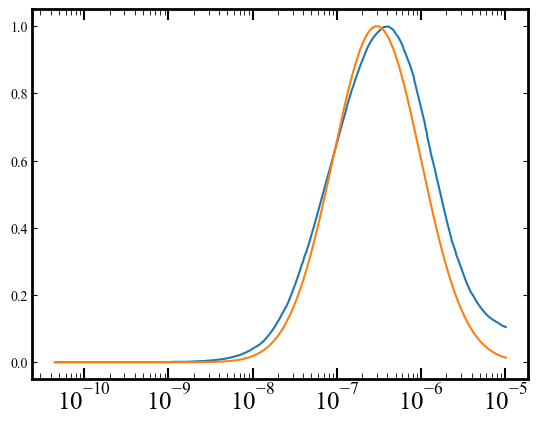

In [6]:
plt.semilogx(P_Mmax_sec[:,0],P_Mmax_sec[:,1])
plt.semilogx(P_Mmax_sec[:,0],np.exp(-np.log(P_Mmax_sec[:,0]/3e-7)**2/(2*1.2**2)))

In [8]:
from scipy.interpolate import interp1d
from scipy.integrate import cumtrapz

def hdi_from_pdf_sampling(pdf_func, x_range, n_samples=1000000, credible_mass=0.95):
    """
    通过对已知的 PDF 进行采样来计算 HDI。
    
    参数:
    pdf_func: 接收 array 返回 array 的 PDF 函数
    x_range: (min, max) 覆盖概率分布主要区域的范围
    n_samples: 采样点数，越多越精确
    credible_mass: 置信水平
    """
    # 1. 在 x_range 内离散化 PDF
    x = np.linspace(x_range[0], x_range[1], 10000)
    pdf_y = pdf_func(10**x)
    pdf_y /= pdf_y.sum() # 归一化
    
    # 2. 计算 CDF
    cdf_y = np.cumsum(pdf_y)
    
    # 3. 逆变换采样 (Inverse Transform Sampling)
    # 构造从 [0, 1] 映射到 x 的逆 CDF 函数
    inv_cdf = interp1d(cdf_y, x, bounds_error=False, fill_value=0.0)
    
    # 生成均匀分布随机数并映射到我们的分布
    random_u = np.random.uniform(0, 1, n_samples)
    samples = inv_cdf(random_u)
    
    # 4. 计算 HDI
    sorted_samples = np.sort(samples)
    interval_idx_inc = int(np.floor(credible_mass * n_samples))
    n_intervals = n_samples - interval_idx_inc
    
    # 寻找最小宽度的区间
    widths = sorted_samples[interval_idx_inc:] - sorted_samples[:n_intervals]
    min_idx = np.argmin(widths)
    
    return 10**sorted_samples[min_idx], 10**sorted_samples[min_idx + interval_idx_inc]

hdi_from_pdf_sampling(P_fmax_sec,[10,9],credible_mass=0.95)

(4469775583.703612, 9999997098.590727)

In [9]:
def likelihood_plot(f, P, color, label, alpha=1,zorder=1):
    best_fit = f[np.argmax(P(f))]
    ax.axvline(best_fit, color=color, linestyle='--', lw=1.5, alpha=0.8)
    low, up = hdi_from_pdf_sampling(P,[np.log10(f[0]),np.log10(f[-1])],credible_mass=0.95)
    print(label+":%s,%s,%s"%(best_fit,best_fit-low,up-best_fit))
    print(low*1.55e-15,up*1.55e-15)
    
    #up_err = up - best_fit
    #low_err = best_fit - low
    
    mask = (f >= low) & (f <= up)
    ax.fill_between(f[mask], 0, gaussian_filter1d(P(f)[mask],sigma=2), color=color, alpha=0.3,zorder=zorder)
    
    # 提取科学计数法的指数 (以 best_fit 为准)
    #exponent = int(np.floor(np.log10(abs(best_fit))))
    #factor = 10**exponent
    
    # 缩放到 1-10 之间的数值
    #val = best_fit / factor
    #up = up_err / factor
    #low = low_err / factor

    ax.plot(f, gaussian_filter1d(P(f),sigma=2), color=color, lw=4, label=label,alpha=alpha,zorder=zorder)
    #ax.plot(f, P(f), color=color, lw=4, label=label+(r":$\,{:.2f}^{{+{:.2f}}}_{{-{:.2f}}} \times 10^{{{:d}}}$"
               #.format(val, up, low, exponent)),alpha=alpha)
    
    

All:28566224385.27786,9596251688.037773,15825108635.702038
2.940345768072213e-05 6.880656618251884e-05
Secure:20564690243.427326,15071562956.44476,63570589361.151505
8.51434729482298e-06 0.0001304096833870972


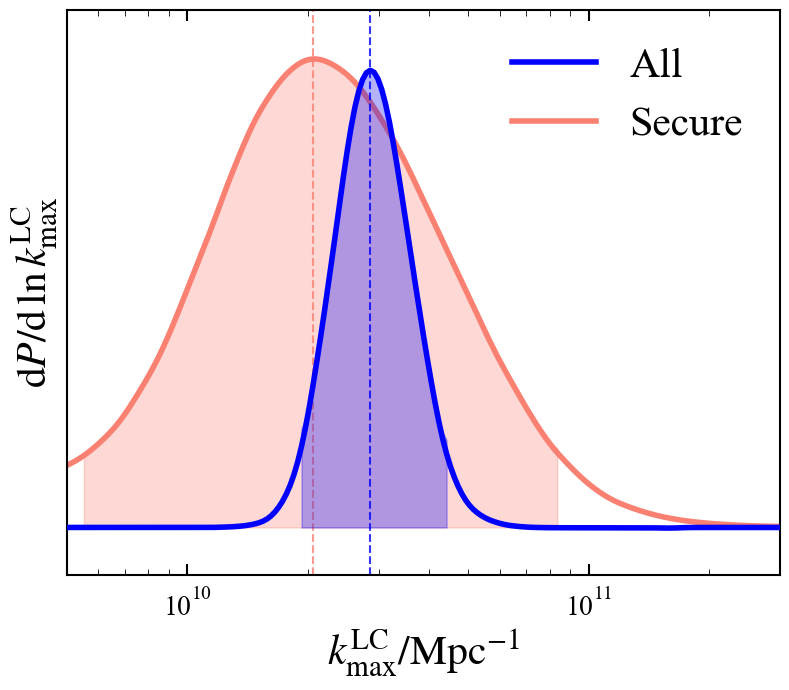

In [10]:
# 1. 设置画布风格
plt.rcParams['axes.linewidth'] = 2
fig, ax = plt.subplots(figsize=(8, 7))

plt.rcParams.update({
    # 尝试加载 Times New Roman, 备选使用 serif
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "Times"],
    "mathtext.fontset": "stix",      # 使数学公式字体更接近 Times
    "axes.unicode_minus": False,     # 正常显示负号
    
    "font.weight": 3,           # 全局文字加粗
    
    # 边框与刻度
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,               # 开启上方刻度 (Frame -> True)
    "ytick.right": True,             # 开启右侧刻度
    "xtick.major.pad": 10,            # 刻度与标签的间距
    "ytick.major.pad": 10,
    
    # 字体大小设置 (还原 BaseStyle -> 24 和 LabelStyle -> 16)
    "axes.labelsize": 30,            # 对应 Mathematica 的 BaseStyle
    "xtick.labelsize": 20,           # 对应 LabelStyle -> 16
    "ytick.labelsize": 20,
    "legend.fontsize": 30,
})


# 2. 生成 x 轴数据 (M_PBH 采用对数刻度)
# 范围从 10^-11 到 10^-5
klist = np.geomspace(1e9, 7e11, 300)


minimize_scalar(lambda x: -P_fmin_int(x), bounds=(1e-8, 5e-8), method='bounded')

#ax.plot(flist, P_fmax_all(flist), color='gray', lw=4, label=r'Total $\mathcal{L}_{\mathrm{LC}}$',alpha=0.5)
likelihood_plot(klist,P_fmax_all,color="blue",label="All",zorder=10)

#ax.plot(flist, P_fmax_sec(flist), color='black', lw=4, label=r'Total $\mathcal{L}_{\mathrm{LC}}$')
likelihood_plot(klist,P_fmax_sec,color="salmon",label="Secure")



# 7. 格式化坐标轴 (关键：对数刻度和样式)
ax.set_xscale('log')
ax.set_xlim(5e9, 3e11)
ax.set_ylim(-0.1, 1.1)

# 设置刻度向内
#ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=18, length=8, width=2)
#ax.tick_params(which='minor', length=4)

# 标签
ax.set_xlabel(r'$k^{\mathrm{LC}}_{\mathrm{max}}/\text{Mpc}^{-1}$', fontsize=30)
ax.set_ylabel(r'${\rm d}P/{\rm d}\, \ln k^{\mathrm{LC}}_{\mathrm{max}}$', fontsize=30)

# 隐藏 y 轴刻度 (符合原图风格)
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(False)

plt.legend(frameon=False)

plt.savefig(figp + "kmax.pdf", transparent = True, bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

fmin:11307323.879923193,2469064.6511469465,4629311.433387337
1.3699301804603182e-08 2.4701784735631322e-08


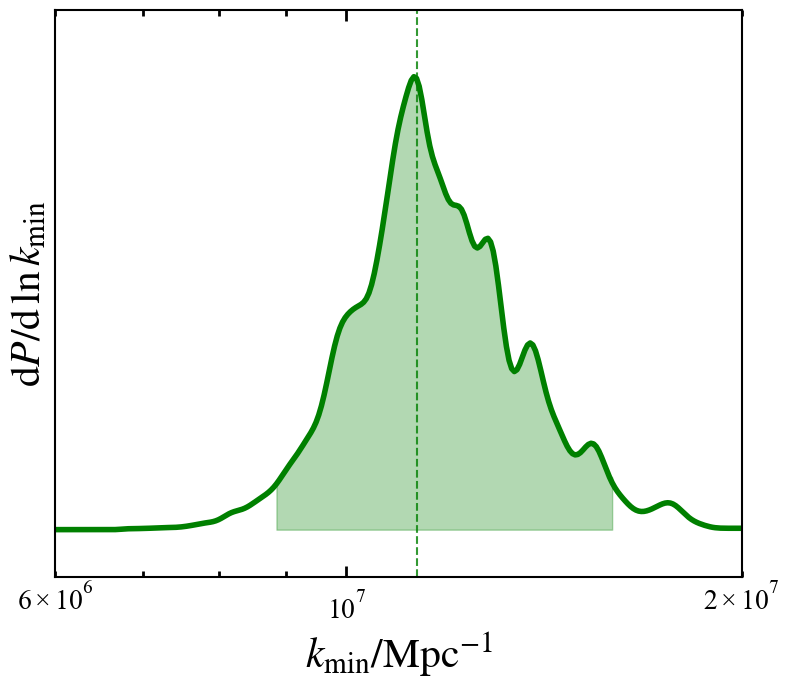

In [13]:
# 1. 设置画布风格

fig, ax = plt.subplots(figsize=(8, 7))

plt.rcParams.update({
    # 尝试加载 Times New Roman, 备选使用 serif
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "Times"],
    "mathtext.fontset": "stix",      # 使数学公式字体更接近 Times
    "axes.unicode_minus": False,     # 正常显示负号
    
    "font.weight": 3,           # 全局文字加粗
    
    # 边框与刻度
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,               # 开启上方刻度 (Frame -> True)
    "ytick.right": True,             # 开启右侧刻度
    "xtick.major.pad": 10,            # 刻度与标签的间距
    "ytick.major.pad": 10,
    
    # 字体大小设置 (还原 BaseStyle -> 24 和 LabelStyle -> 16)
    "axes.labelsize": 30,            # 对应 Mathematica 的 BaseStyle
    "xtick.labelsize": 20,           # 对应 LabelStyle -> 16
    "ytick.labelsize": 20,
    "legend.fontsize": 30,
})


klist = np.geomspace(5e6, 2e7, 300)

#ax.plot(flist, P_fmin_int(flist), color='black', lw=4, label=r'Total $\mathcal{L}_{\mathrm{LC}}$')
likelihood_plot(klist,P_fmin_int,color="green",label="fmin")

# 格式化坐标轴 (关键：对数刻度和样式)
ax.set_xscale('log')
ax.set_xlim(6e6, 2e7)
ax.set_ylim(-0.1, 1.1)

# 设置刻度向内
ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=20, length=8, width=2)
ax.tick_params(which='minor', length=4)


for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(False)

# 标签
ax.set_xlabel(r'$k_{\mathrm{min}}/\text{Mpc}^{-1}$', fontsize=30)
ax.set_ylabel(r'${\rm d}P/{\rm d}\, \ln k_{\mathrm{min}}$', fontsize=30)

# 隐藏 y 轴刻度 (符合原图风格)
ax.set_yticks([])

plt.savefig(figp + "kmin.pdf", transparent = True, bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

# IGW

In [15]:
igw = np.loadtxt(datap+"GWarray_results_10e3.csv", delimiter=",")

A=3.5e-2

transfer = 1.62e-5* (g_rho(fmin,is_freq=True)/106.75)**(-1/3)

flist = np.geomspace(1e-9, 1e-3,200)

igwint = interp1d(
    igw[:, 0], igw[:, 1], kind="cubic", bounds_error=False, fill_value=0.0
)

def IGW(f,fmin,fmax):
    Ogw = np.ones(len(f))
    transfer = 1.62e-5 * (g_rho(fmin, is_freq=True) / 106.75) ** (-1 / 3)
    Ogw[f<10*fmin] = igwint(f[f<10*fmin]/fmin*10**-3) * transfer * (g_rho(f[f<10*fmin], is_freq=True) / g_rho(fmin, is_freq=True)) ** (-1 / 3)* A**2
    Ogw[np.logical_and(f>10*fmin,f<fmax/10)] = igwint(10**-1.5) * transfer * (g_rho(f[np.logical_and(f>10*fmin,f<fmax/10)], is_freq=True) / g_rho(fmin, is_freq=True)) ** (-1 / 3)* A**2
    Ogw[f>fmax/10] = igwint(f[f>fmax/10]/fmax) * transfer * (g_rho(f[f>fmax/10], is_freq=True) / g_rho(fmin, is_freq=True)) ** (-1 / 3)* A**2
    return Ogw

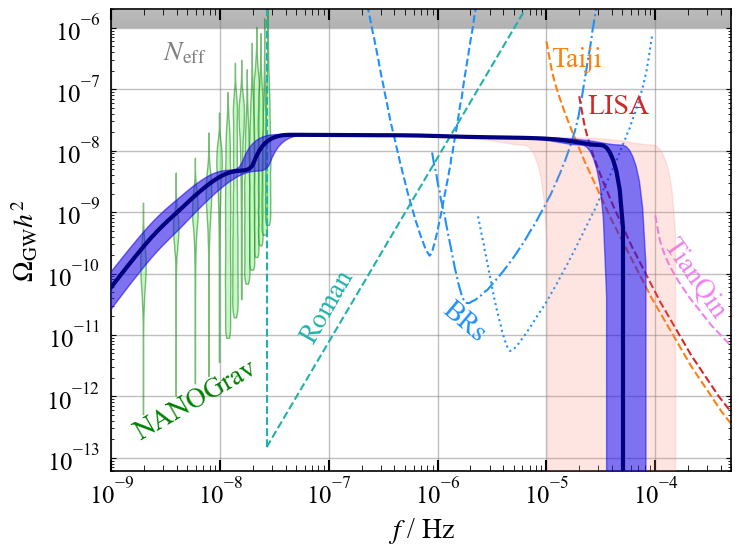

In [22]:
# plot setting

plt.rcParams.update({
    # 尝试加载 Times New Roman, 备选使用 serif
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "Times"],
    "mathtext.fontset": "stix",      # 使数学公式字体更接近 Times
    "axes.unicode_minus": False,     # 正常显示负号
    
    "font.weight": 3,           # 全局文字加粗
    
    # 边框与刻度
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,               # 开启上方刻度 (Frame -> True)
    "ytick.right": True,             # 开启右侧刻度
    "xtick.major.pad": 8,            # 刻度与标签的间距
    "ytick.major.pad": 8,
    
    # 字体大小设置 (还原 BaseStyle -> 24 和 LabelStyle -> 16)
    "axes.labelsize": 24,            # 对应 Mathematica 的 BaseStyle
    "xtick.labelsize": 18,           # 对应 LabelStyle -> 16
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})


fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xscale('log')
ax.set_yscale('log')

plt.xlim(10e-10,5e-4)
plt.ylim(6e-14,2e-6)

GW_dir = datap + "GW detector/"

inital = np.loadtxt(GW_dir + "NANOGrav.csv")
blob = inital.reshape((30, 201, 2))
f = blob[:, :, 0]
Ogw = blob[:, :, 1]

from matplotlib.patches import Polygon

for i in range(14):
    #idx = Ogw[i]> f[i]**2*10**6
    idx = Ogw[i]> 5e-13*(f[i]/f[0])

    poly = Polygon(np.column_stack([f[i,idx], Ogw[i,idx]]),
               facecolor='lightgreen',
               edgecolor='green',alpha=0.5)

    ax.add_patch(poly)
ax.text(s="NANOGrav",x=1.5e-9,y=2e-13,c="green",rotation=30,fontsize=20)

LLR = np.loadtxt(GW_dir+"Binary-resonance/LLR.csv",delimiter=",")
eLO = np.loadtxt(GW_dir+"Binary-resonance/eLO.csv",delimiter=",")
eSLR = np.loadtxt(GW_dir+"Binary-resonance/eSLR.csv",delimiter=",")

plt.plot(LLR[:,0],LLR[:,1]*0.7**2,ls="--", zorder=1,color='dodgerblue')
plt.plot(eLO[:,0],eLO[:,1]*0.7**2,ls="-.", zorder=1,color='dodgerblue')
plt.plot(eSLR[:,0],eSLR[:,1]*0.7**2,ls=":", zorder=1,color='dodgerblue')
ax.text(s="BRs",x=1e-6,y=8e-12,c='dodgerblue',rotation=-40,fontsize=20)

Roman = np.loadtxt(GW_dir+"RomanOMEGA.dat")
#plt.fill_between(10**Roman[:,0],10**Roman[:,1],10**(0*10**Roman[:,0]),color="#e0f7fa",alpha=0.5, zorder=1)
plt.plot(10**Roman[:,0],10**Roman[:,1],color="lightseagreen",ls="--", zorder=1)
plt.vlines(10**Roman[0,0],10**Roman[0,1],1,color="lightseagreen",ls="--", zorder=1)
ax.text(s="Roman",x=5e-8,y=8e-12,c="lightseagreen",rotation=60,fontsize=20)

LISA = np.loadtxt(GW_dir+"PLI_data/LISA.txt")
plt.plot(LISA[:,0],LISA[:,1], color="#d62728",ls="--")
ax.text(s="LISA",x=2.4e-5,y=4e-8,c="#d62728",rotation=0,fontsize=20)

Taiji = np.loadtxt(GW_dir+"PLI_data/Taiji.txt")
plt.plot(Taiji[:,0],Taiji[:,1], color="#ff7f0e",ls="--")
ax.text(s="Taiji",x=1.1e-5,y=2.4e-7,c="#ff7f0e",rotation=0,fontsize=20)

TianQin = np.loadtxt(GW_dir+"PLI_data/TianQin.txt")
plt.plot(TianQin[:,0],TianQin[:,1], color="Violet",ls="--")
ax.text(s="TianQin",x=1.05e-4,y=2e-11,c="Violet",rotation=-55,fontsize=20)

#plt.axhline(y=1e-6, ls="--",color="gray")
gradient = np.linspace(0, 1, 100).reshape(-1, 1)  # 创建一个从1到0的竖直渐变
gradient = np.hstack([gradient] * 100)            # 将其扩展为100列

# 在曲线下方绘制渐变图像
extent = [1e-9, 1e-3, 1e-6, 1e-5]
ax.imshow(gradient, aspect='auto', cmap='Greys', extent=extent, alpha=0.3)
ax.text(s=r"$N_{\mathrm{eff}}$",x=3e-9,y=3e-7, color="gray",fontsize=20)

ax.fill_between(flist,IGW(flist,10**-7.6072,8.714908522275318e-06 ),IGW(flist,10**-7.863,0.0001336041847062942),alpha=0.2,label="Secure",color="salmon",zorder=10)
ax.fill_between(flist,IGW(flist,10**-7.6072,2.955392037824669e-05),IGW(flist,10**-7.863,6.906215434360106e-05),alpha=0.5,label="All",color="blue",zorder=10)
ax.loglog(flist,IGW(flist,1.13e7*1.55e-15, 28566224385.27786*1.55e-15),color="#000080",zorder=10,lw=3)

# axis lable & tick
plt.xlabel(r"$f$ / Hz",fontsize=20)
plt.ylabel(r"$\Omega_\mathrm{GW}h^2$",fontsize=20)
    
ax.xaxis.set_tick_params(pad=5)

ax.grid(True, which='major', axis='both', color='gray', linestyle='-', linewidth=1, alpha=0.5)
# 确保网格在曲线下方
ax.set_axisbelow(True)

#plt.legend(loc=(0.5,0.1),fontsize="x-small",ncols=1,frameon=True,framealpha=1,handlelength=3.5)

#xticks = 10**np.arange(-10, -1)
ax.set_xticklabels([], minor=True)
ax.set_yticklabels([], minor=True)
plt.savefig(figp + "Ogwnsvsfp2.pdf", transparent = True, bbox_inches='tight', dpi=300)


In [23]:
igw = np.loadtxt(datap+"GWarray_results_10e3.csv", delimiter=",")

fmin = 10**-7.65 #Hz

fmax = 1e-3

transfer = 1.62e-5* (g_rho(fmin,is_freq=True)/106.75)**(-1/3)

flist = np.geomspace(fmin*1e-3, fmax*10,200)

igwint = interp1d(
    igw[:, 0], igw[:, 1], kind="cubic", bounds_error=False, fill_value=0.0
)

def nIGW(f,fmin,fmax):
    Ogw = np.ones(len(f))
    transfer = 1.62e-5 * (g_rho(fmin, is_freq=True) / 106.75) ** (-1 / 3)
    Ogw[f<10*fmin] = igwint(f[f<10*fmin]/fmin*10**-3) * transfer * (g_rho(f[f<10*fmin], is_freq=True) / g_rho(fmin, is_freq=True)) ** (-1 / 3)
    Ogw[np.logical_and(f>10*fmin,f<fmax/10)] = igwint(10**-1.5) * transfer * (g_rho(f[np.logical_and(f>10*fmin,f<fmax/10)], is_freq=True) / g_rho(fmin, is_freq=True)) ** (-1 / 3)
    Ogw[f>fmax/10] = igwint(f[f>fmax/10]/fmax) * transfer * (g_rho(f[f>fmax/10], is_freq=True) / g_rho(fmin, is_freq=True)) ** (-1 / 3)
    return Ogw

In [25]:
# plot setting

plt.rcParams.update({
    # 尝试加载 Times New Roman, 备选使用 serif
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "Times"],
    "mathtext.fontset": "stix",      # 使数学公式字体更接近 Times
    "axes.unicode_minus": False,     # 正常显示负号
    
    "font.weight": 3,           # 全局文字加粗
    
    # 边框与刻度
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,               # 开启上方刻度 (Frame -> True)
    "ytick.right": True,             # 开启右侧刻度
    "xtick.major.pad": 8,            # 刻度与标签的间距
    "ytick.major.pad": 8,
    
    # 字体大小设置 (还原 BaseStyle -> 24 和 LabelStyle -> 16)
    "axes.labelsize": 24,            # 对应 Mathematica 的 BaseStyle
    "xtick.labelsize": 18,           # 对应 LabelStyle -> 16
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})


# transfer Ogw_eq to Ogwh^2_0
gs = 86.25
transfer = 1.62e-5* (gs/106.75)**(-1/3)

df = pd.read_csv(datap + "Ogwset.csv",index_col=0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xscale('log')
ax.set_yscale('log')

plt.xlim(10e-10,5e-4)
plt.ylim(6e-14,2e-6)


NANOGrav_dir = "/Users/wangao/科研/2023/PTA-IGW/relevant_code/Obsolete_code/NANOGrav_Fig3_Huake_Guo/"
inital = np.loadtxt(NANOGrav_dir + "blob_flat.csv")
blob = inital.reshape((30, 201, 2))
f = blob[:, :, 0]
Ogw = blob[:, :, 1]

from matplotlib.patches import Polygon

for i in range(14):
    #idx = Ogw[i]> f[i]**2*10**6
    idx = Ogw[i]> 5e-13*(f[i]/f[0])

    poly = Polygon(np.column_stack([f[i,idx], Ogw[i,idx]]),
               facecolor='gray',
               edgecolor='black',alpha=0.3)

    ax.add_patch(poly)
ax.text(s="NANOGrav",x=1.5e-9,y=2e-13,c="gray",rotation=30,fontsize=20)

LLR = np.loadtxt(datap+"/Binary-resonance/LLR.csv",delimiter=",")
eLO = np.loadtxt(datap+"/Binary-resonance/eLO.csv",delimiter=",")
eSLR = np.loadtxt(datap+"/Binary-resonance/eSLR.csv",delimiter=",")

plt.plot(LLR[:,0],LLR[:,1]*0.7**2,ls="--", zorder=1,color='dodgerblue')
plt.plot(eLO[:,0],eLO[:,1]*0.7**2,ls="-.", zorder=1,color='dodgerblue')
plt.plot(eSLR[:,0],eSLR[:,1]*0.7**2,ls=":", zorder=1,color='dodgerblue')
ax.text(s="BRs",x=1e-6,y=8e-12,c='dodgerblue',rotation=-40,fontsize=20)

Roman = np.loadtxt("/Users/wangao/Desktop/Work/Astrometry/data/Roman/RomanOMEGA.dat")
#plt.fill_between(10**Roman[:,0],10**Roman[:,1],10**(0*10**Roman[:,0]),color="#e0f7fa",alpha=0.5, zorder=1)
plt.plot(10**Roman[:,0],10**Roman[:,1],color="lightseagreen",ls="--", zorder=1)
plt.vlines(10**Roman[0,0],10**Roman[0,1],1,color="lightseagreen",ls="--", zorder=1)
ax.text(s="Roman",x=5e-8,y=8e-12,c="lightseagreen",rotation=60,fontsize=20)

LISA = np.loadtxt(datap+"PLI_data/LISA.txt")
plt.plot(LISA[:,0],LISA[:,1], color="#d62728",ls="--")
ax.text(s="LISA",x=2.4e-5,y=4e-8,c="#d62728",rotation=0,fontsize=20)

Taiji = np.loadtxt(datap+"PLI_data/Taiji.txt")
plt.plot(Taiji[:,0],Taiji[:,1], color="#ff7f0e",ls="--")
ax.text(s="Taiji",x=1.1e-5,y=2.4e-7,c="#ff7f0e",rotation=0,fontsize=20)

TianQin = np.loadtxt(datap+"PLI_data/TianQin.txt")
plt.plot(TianQin[:,0],TianQin[:,1], color="Violet",ls="--")
ax.text(s="TianQin",x=1.05e-4,y=2e-11,c="Violet",rotation=-55,fontsize=20)

#plt.axhline(y=1e-6, ls="--",color="gray")
gradient = np.linspace(0, 1, 100).reshape(-1, 1)  # 创建一个从1到0的竖直渐变
gradient = np.hstack([gradient] * 100)            # 将其扩展为100列

# 在曲线下方绘制渐变图像
extent = [1e-9, 1e-3, 1e-6, 1e-5]
ax.imshow(gradient, aspect='auto', cmap='Greys', extent=extent, alpha=0.3)
ax.text(s=r"$N_{\mathrm{eff}}$",x=3e-9,y=3e-7, color="gray",fontsize=20)

colors = ['#000000', '#ffc006', 'cyan']

ax.loglog(flist,(3.52e-2)**2*nIGW(flist,1.19e7*1.55e-15,3.08e10*1.55e-15),color=colors[0],zorder=10,lw=2.5,alpha=1)
ax.loglog(flist,(2.50e-2)**2*nIGW(flist,8.15e6*1.55e-15, 3.08e10*1.55e-15),color=colors[1],zorder=10,lw=2.5,alpha=1)
ax.loglog(flist,(1.41e-2)**2*nIGW(flist,3.80e6*1.55e-15, 3.00e10*1.55e-15),color=colors[2],zorder=10,lw=2.5,alpha=1)
ax.loglog(flist,(3.52e-2)**2*nIGW(flist,1.19e3*1.55e-15,3.08e10*1.55e-15),color=colors[0],zorder=10,lw=1,alpha=1,ls="--")
ax.loglog(flist,(2.49e-2)**2*nIGW(flist,8.15e3*1.55e-15, 3.14e10*1.55e-15),color=colors[1],zorder=10,lw=1,alpha=1,ls="--")
ax.loglog(flist,(1.41e-2)**2*nIGW(flist,3.80e3*1.55e-15, 3.02e10*1.55e-15),color=colors[2],zorder=10,lw=1,alpha=1,ls="--")



# axis lable & tick
plt.xlabel(r"$f$ / Hz",fontsize=20)
plt.ylabel(r"$\Omega_\mathrm{GW}h^2$",fontsize=20)
    
ax.xaxis.set_tick_params(pad=5)

ax.grid(True, which='major', axis='both', color='gray', linestyle='-', linewidth=1, alpha=0.5)
# 确保网格在曲线下方
ax.set_axisbelow(True)

#plt.legend(loc=(0.5,0.1),fontsize="x-small",ncols=1,frameon=True,framealpha=1,handlelength=3.5)

#xticks = 10**np.arange(-10, -1)
ax.set_xticklabels([], minor=True)
ax.set_yticklabels([], minor=True)
plt.savefig(figp + "gw_threshold.pdf", transparent = True, bbox_inches='tight', dpi=300)



FileNotFoundError: [Errno 2] No such file or directory: '/Users/wangao/Desktop/Work/HSC/code/data/Ogwset.csv'